
### **Sales Forecasting (Time Series Regression)**

**Problem**
- Forecast future product sales based on historical data to optimize inventory, supply chain, and revenue planning.

**Approach**
1. **Lag Features & Rolling Statistics**: Created features like `lag_1`, `lag_7`, `lag_14`, `rolling_mean_7`, and `rolling_std_7` to capture temporal dependencies.
2. **XGBoost Regression**: Predicted next-period sales using lagged features, handling non-linear trends effectively.
3. **Prophet Model (Optional)**: Used Facebook’s Prophet for robust time-series forecasting, capturing seasonality and trends automatically.
4. **Evaluation Metrics**: RMSE and R² score to measure prediction accuracy.

**Key Insights**
* Lag features and rolling statistics significantly improve prediction accuracy.
* XGBoost handles non-linear sales patterns better than simple regression models.
* Prophet is ideal for capturing seasonality and long-term trends in sales data.

**Enterprise Use Case**

* **Inventory Optimization**: Avoid stockouts and overstocking.
* **Supply Chain Planning**: Align procurement and logistics with forecasted demand.
* **Revenue & Budget Planning**: Set realistic sales targets and promotional strategies.
* **Enterprise Integration**: Can be deployed in ERP or BI dashboards for real-time decision making.


### 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

# Prophet library
from prophet import Prophet


e:\Gen AI\Supervised ML\myEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Load Dataset


In [3]:
df = pd.read_csv("Data/mock_kaggle.csv", parse_dates=['data'])
df = df.sort_values('data')
df.set_index('data', inplace=True)

print("Dataset Preview:")
print(df.head())



Dataset Preview:
            venda  estoque  preco
data                             
2014-01-01      0     4972   1.29
2014-01-02     70     4902   1.29
2014-01-03     59     4843   1.29
2014-01-04     93     4750   1.29
2014-01-05     96     4654   1.29


### 3. Feature Engineering for XGBoost

In [5]:
df['lag_1'] = df['venda'].shift(1)
df['lag_7'] = df['venda'].shift(7)
df['rolling_mean_7'] = df['venda'].shift(1).rolling(window=7).mean()
df['rolling_std_7'] = df['venda'].shift(1).rolling(window=7).std()

df.dropna(inplace=True)

X = df[['lag_1','lag_7','rolling_mean_7','rolling_std_7','estoque','preco']]
y = df['venda']



### 4. Train-Test Split

In [6]:
split_idx = int(len(df)*0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

### 5. Train XGBoost Regressor

In [ ]:
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)  # Safe for all XGBoost versions

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### 6. Predictions & Evaluation

XGBoost RMSE: 82.55
XGBoost R2 Score: 0.16


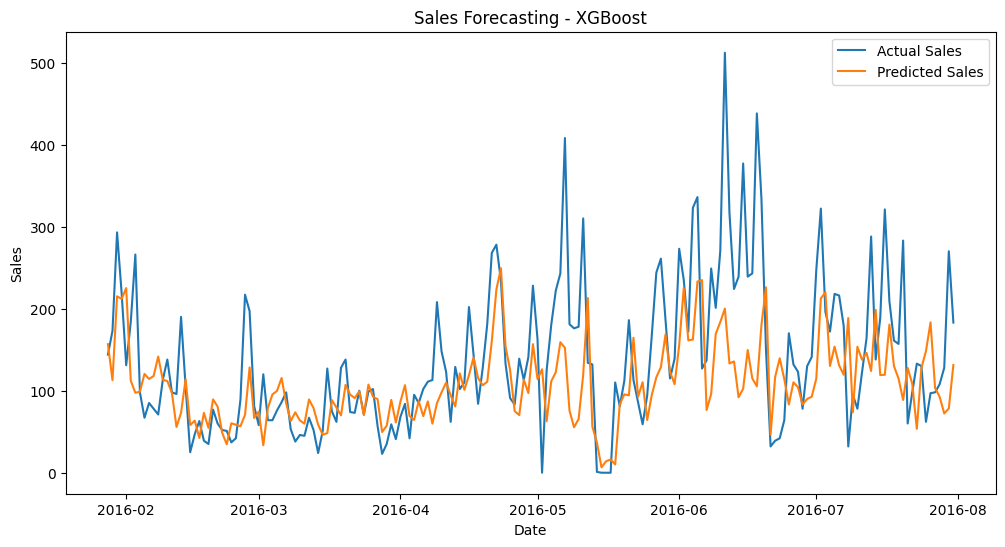

In [8]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost RMSE: {rmse:.2f}")
print(f"XGBoost R2 Score: {r2:.2f}")

# Plot Actual vs Predicted Sales
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual Sales')
plt.plot(y_test.index, y_pred, label='Predicted Sales')
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecasting - XGBoost")
plt.legend()
plt.show()



### 7. Prophet Forecasting

00:23:45 - cmdstanpy - INFO - Chain [1] start processing
00:23:46 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 86.83
Prophet R2 Score: 0.07


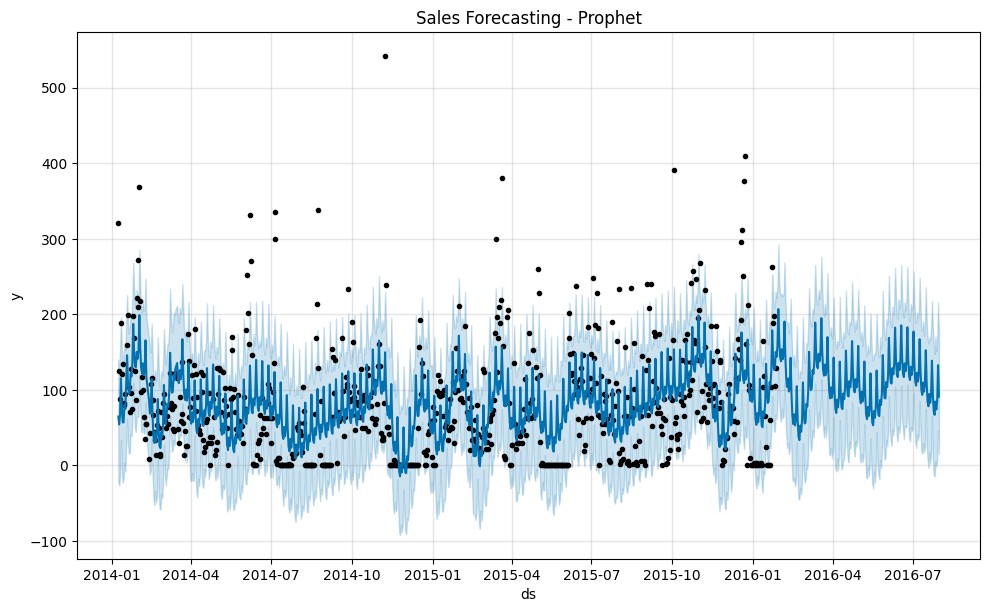

In [9]:
# Prepare data for Prophet
df_prophet = df[['venda']].reset_index().rename(columns={'data':'ds','venda':'y'})

# Train-test split
train_size = int(len(df_prophet)*0.8)
train_prophet = df_prophet[:train_size]
test_prophet = df_prophet[train_size:]

# Initialize and train Prophet model
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet.fit(train_prophet)

# Make future dataframe for test period
future = model_prophet.make_future_dataframe(periods=len(test_prophet))
forecast = model_prophet.predict(future)

# Evaluate Prophet predictions
y_test_prophet = test_prophet['y'].values
y_pred_prophet = forecast['yhat'].values[-len(test_prophet):]

rmse_prophet = np.sqrt(mean_squared_error(y_test_prophet, y_pred_prophet))
r2_prophet = r2_score(y_test_prophet, y_pred_prophet)

print(f"Prophet RMSE: {rmse_prophet:.2f}")
print(f"Prophet R2 Score: {r2_prophet:.2f}")

# Plot Prophet Forecast
model_prophet.plot(forecast)
plt.title("Sales Forecasting - Prophet")
plt.show()
